# Projet DATA SCIENCE - Analyse du Churn Client
Ce notebook est dédié exclusivement à l'Exploration des Données (EDA). L'objectif est de comprendre les caractéristiques des clients et d'identifier les facteurs potentiels de désabonnement.

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


In [8]:
df_temp = pd.read_csv('../data/customer_churn.csv')

df = df_temp.drop("customer_id", axis="columns")
df.head(10)


,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,7,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,5,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,Male,24,Germany,New York,SME,58,Web,Yearly,19,5,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,7,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,6,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0
5,Female,36,India,London,Individual,54,Mobile,Monthly,1,3,...,36.038391,Technical,4.0,1,0.83,0.05,-40,Neutral,1,0
6,Male,23,India,Toronto,SME,54,Mobile,Monthly,21,4,...,36.892928,Billing,4.0,0,0.75,0.46,-3,Neutral,1,0
7,Male,37,Bangladesh,Sydney,Individual,7,Referral,Yearly,17,7,...,25.024133,Technical,4.0,1,0.54,0.13,28,Satisfied,1,0
8,Male,44,India,Delhi,SME,15,Referral,Monthly,29,4,...,32.465536,Technical,2.0,0,0.85,0.13,-24,Satisfied,0,0
9,Female,70,Bangladesh,Berlin,Individual,17,Mobile,Monthly,18,5,...,42.986192,Billing,4.0,0,0.72,0.13,17,Neutral,1,0


In [9]:
df.describe()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


In [ ]:
print(f"Dimensions du dataset :(lignes, clonnes) {df.shape}")
print()

audit_df = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
}).sort_values(by='missing_values', ascending=False)

display(audit_df.head(15))


Dimensions du dataset :(lignes, clonnes) (10000, 31)



,dtype,missing_values,missing_pct
complaint_type,object,2045,20.45
age,int64,0,0.00
gender,object,0,0.00
city,object,0,0.00
customer_segment,object,0,0.00
tenure_months,int64,0,0.00
country,object,0,0.00
contract_type,object,0,0.00
monthly_logins,int64,0,0.00
weekly_active_days,int64,0,0.00


In [ ]:
df_corr = df.copy()

label_encoder = LabelEncoder()

for col in df_corr.select_dtypes(include=["object"]).columns:
    df_corr[col] = label_encoder.fit_transform(df_corr[col].astype(str))

df_corr.head()


,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,1,68,1,3,2,22,2,0,26,7,...,13.354360,1,4.0,0,0.71,0.40,27,1,1,0
1,0,57,2,5,1,9,0,0,7,5,...,25.140088,0,2.0,0,0.78,0.33,-19,0,2,1
2,1,24,3,4,2,58,2,2,19,5,...,27.572928,1,3.0,0,0.35,0.49,80,0,1,0
3,1,49,0,2,1,19,0,2,34,7,...,26.420822,2,5.0,1,0.83,0.15,100,0,0,0
4,1,65,1,1,1,52,2,0,20,6,...,26.674579,2,4.0,0,0.65,0.44,21,2,1,0


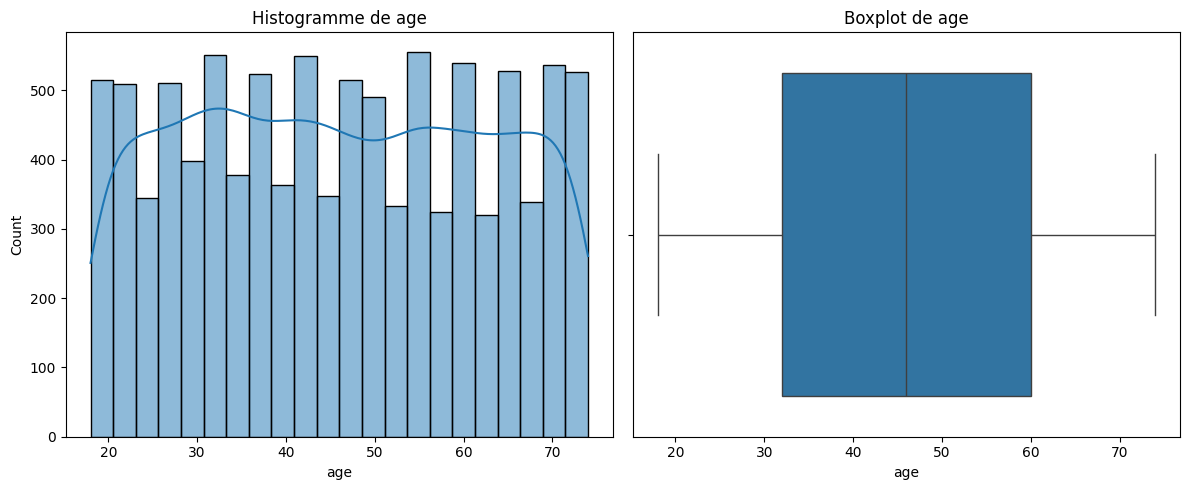

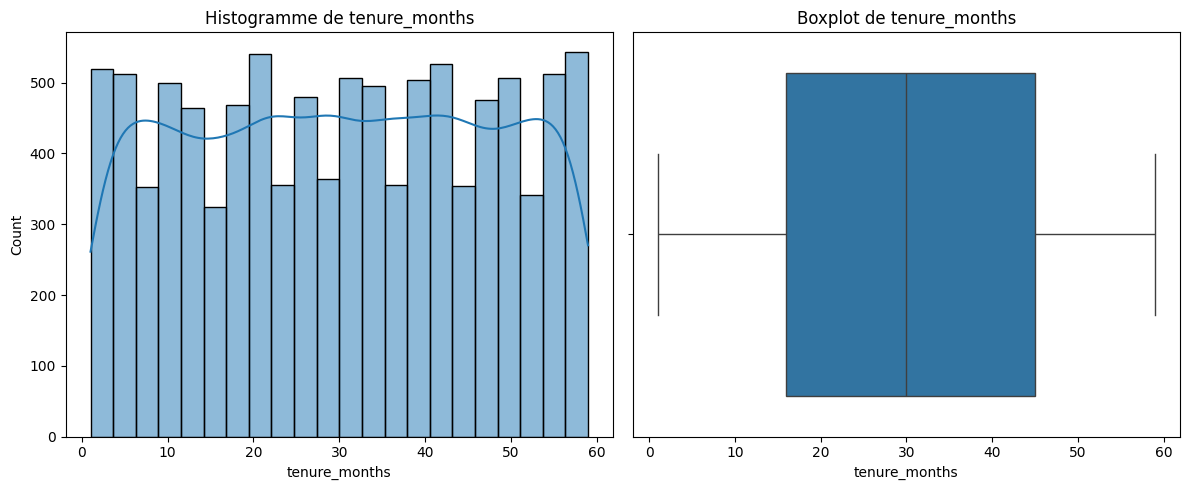

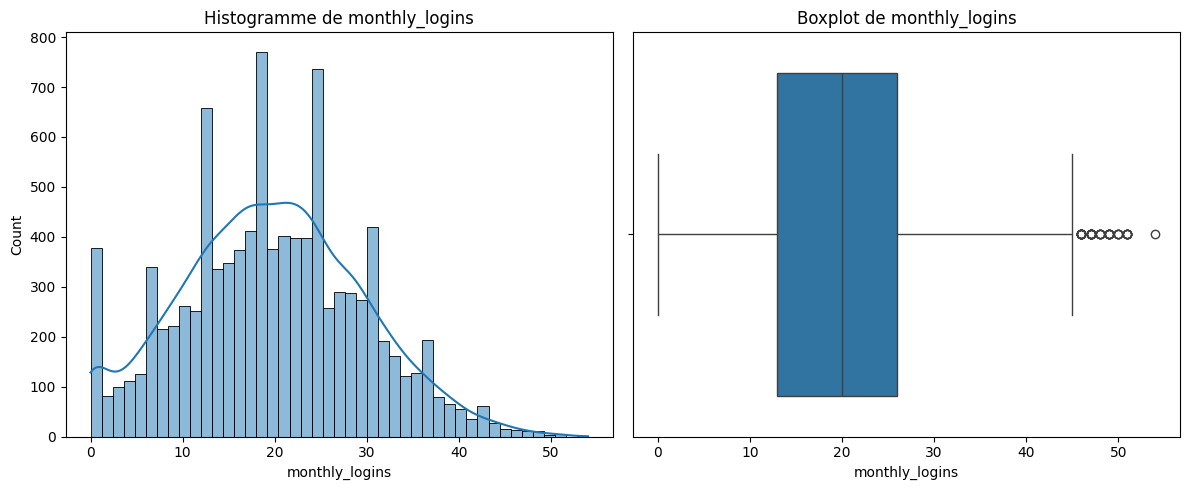

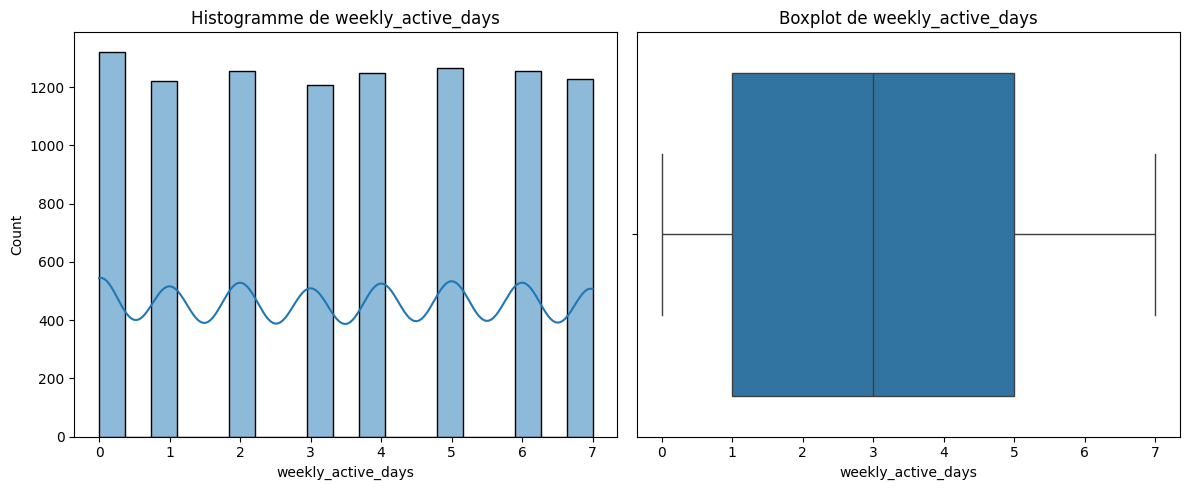

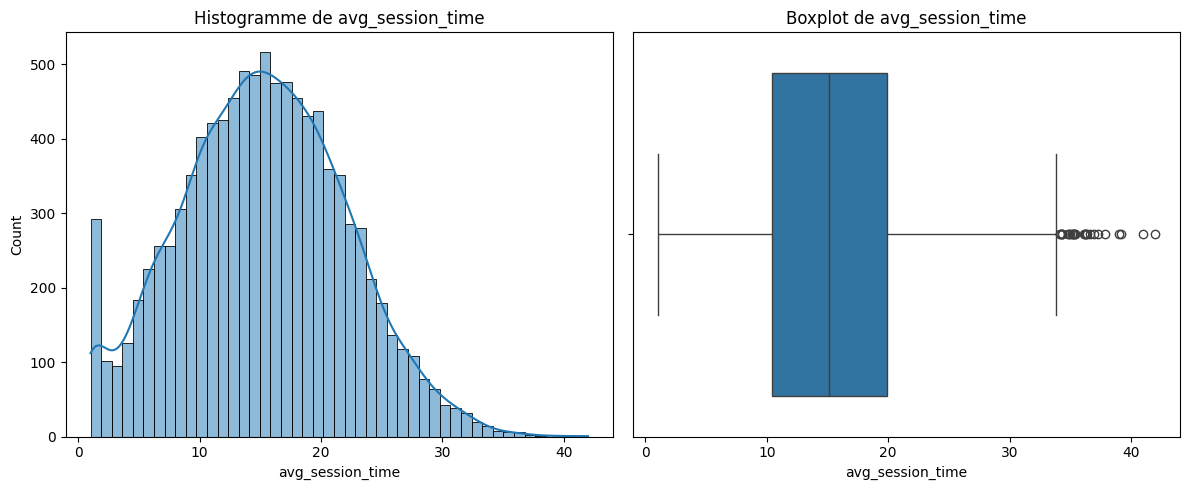

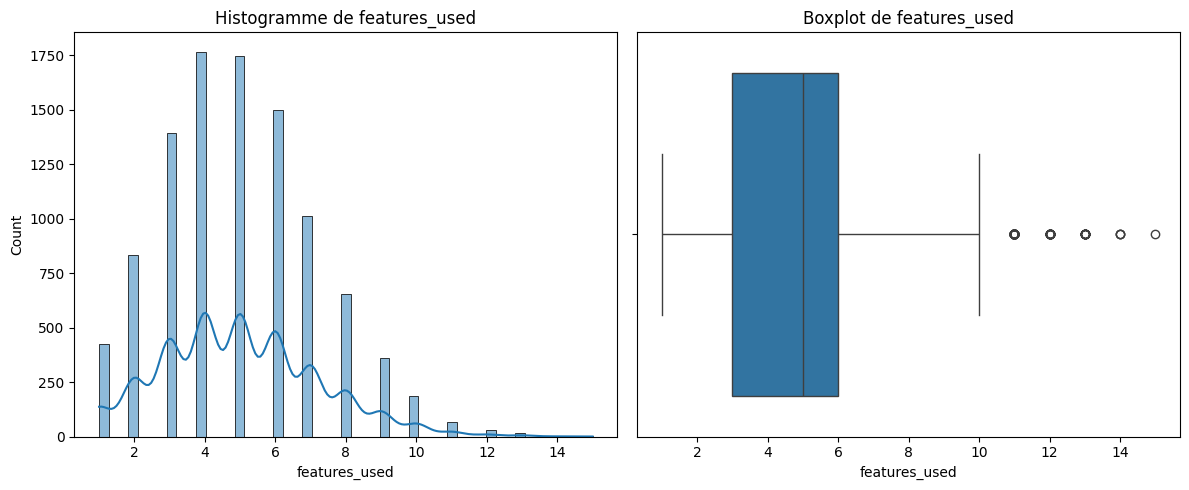

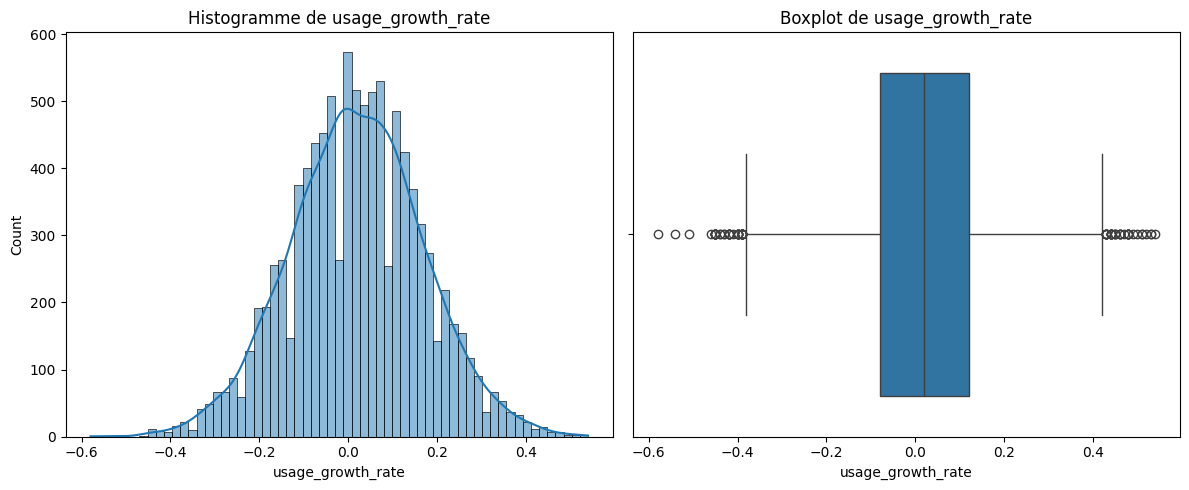

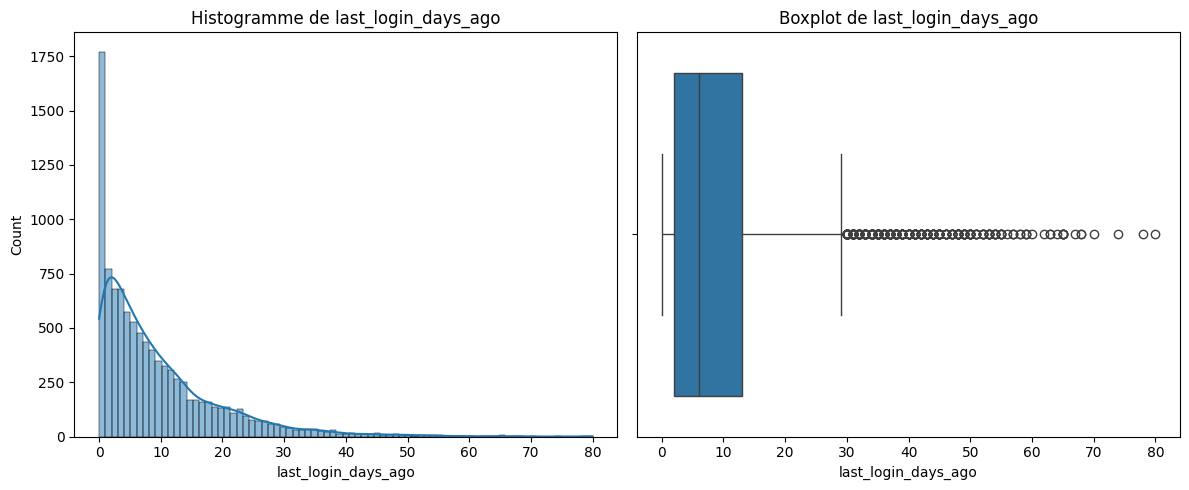

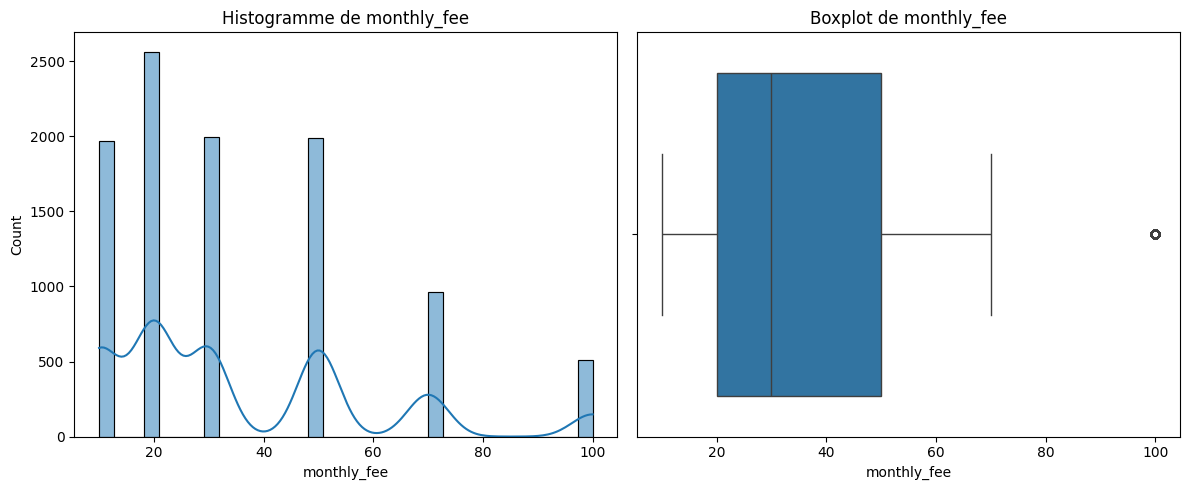

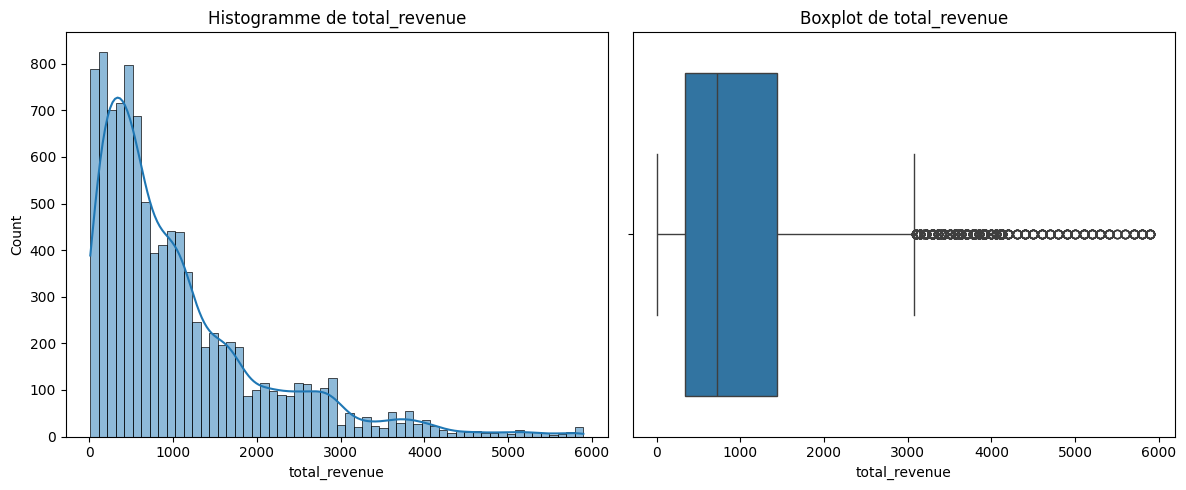

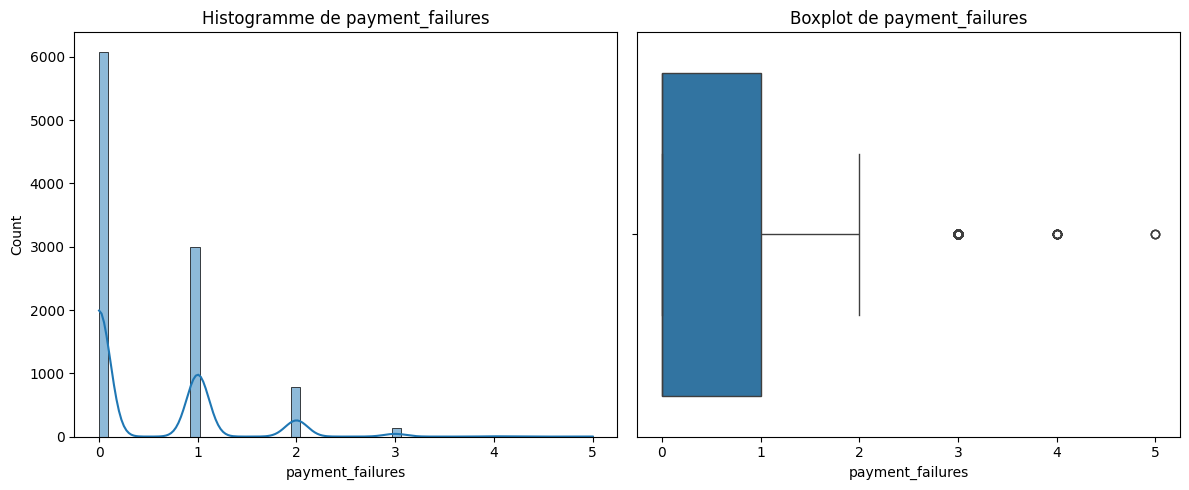

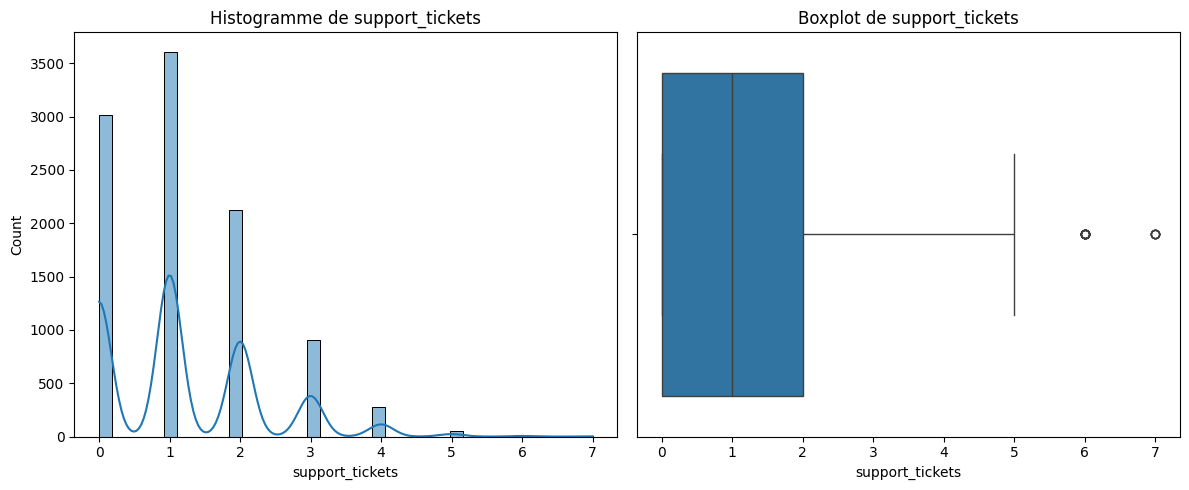

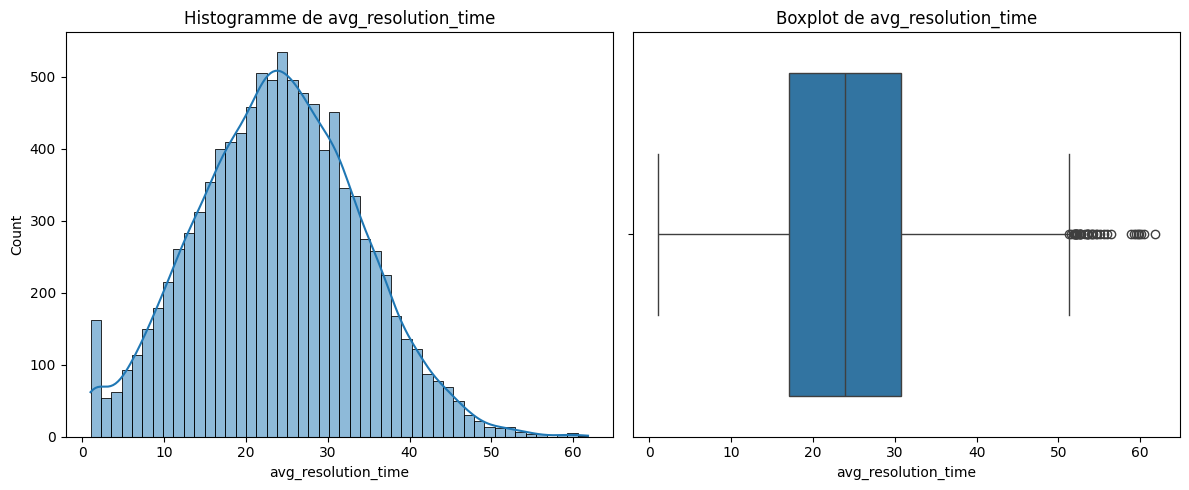

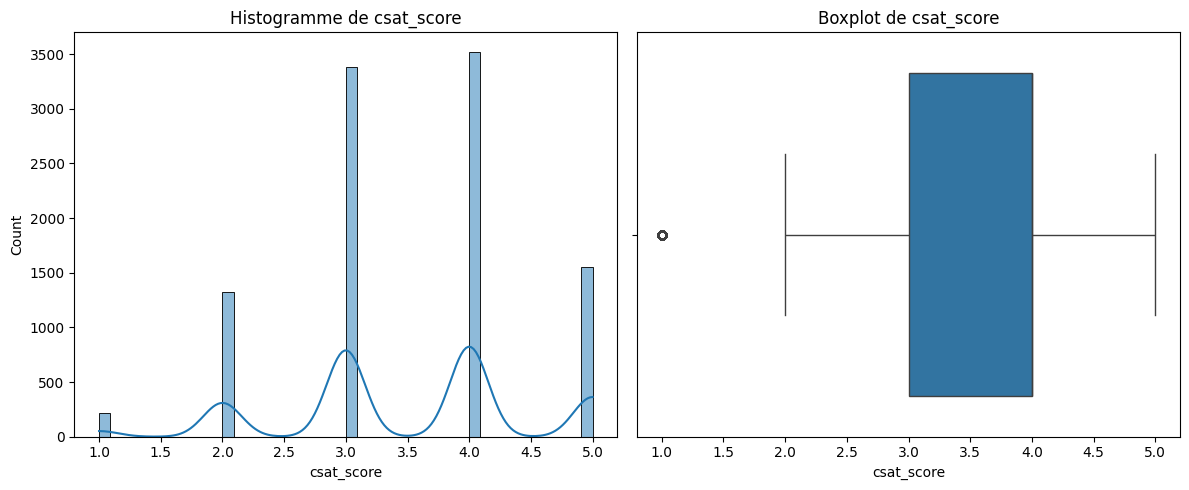

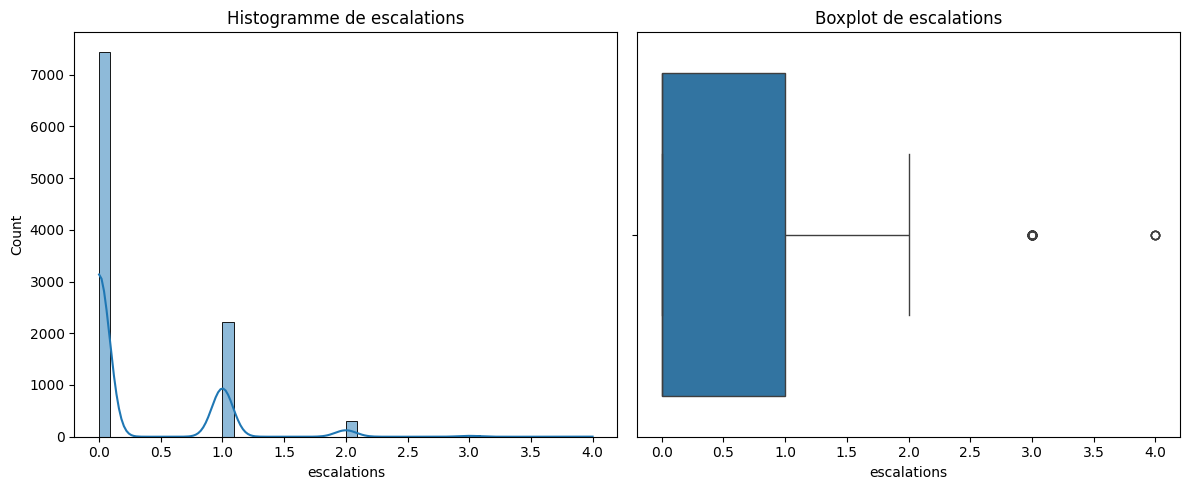

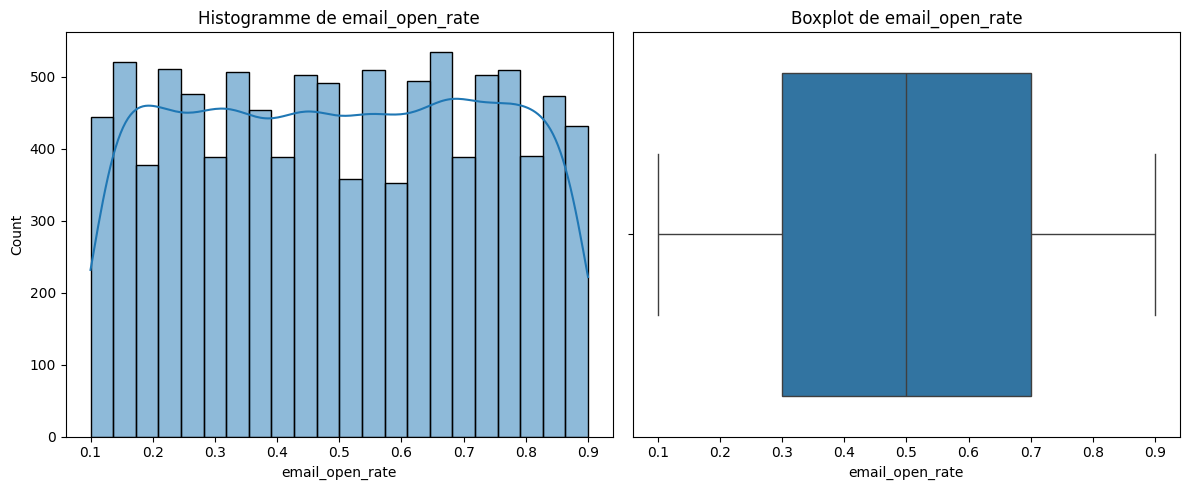

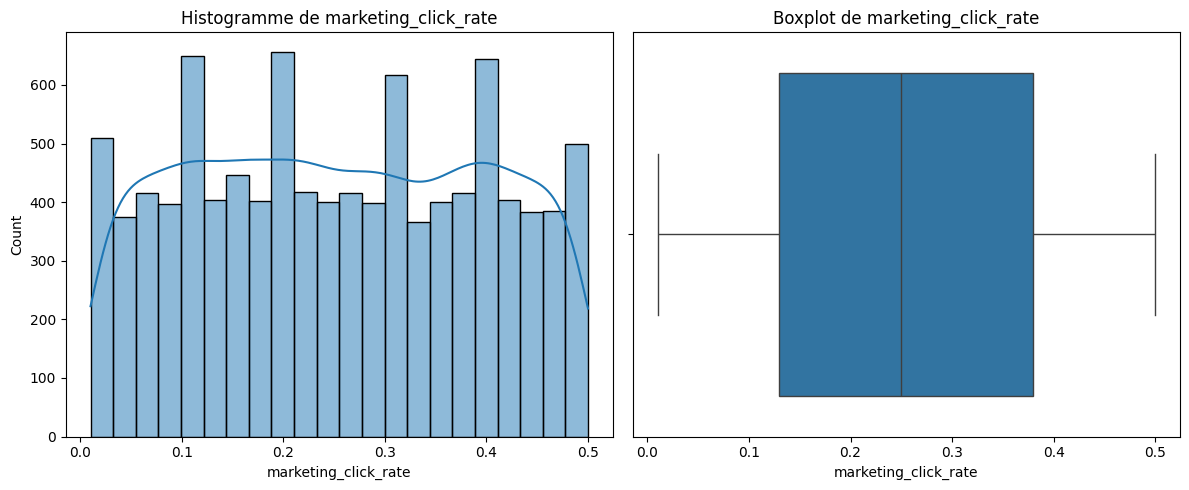

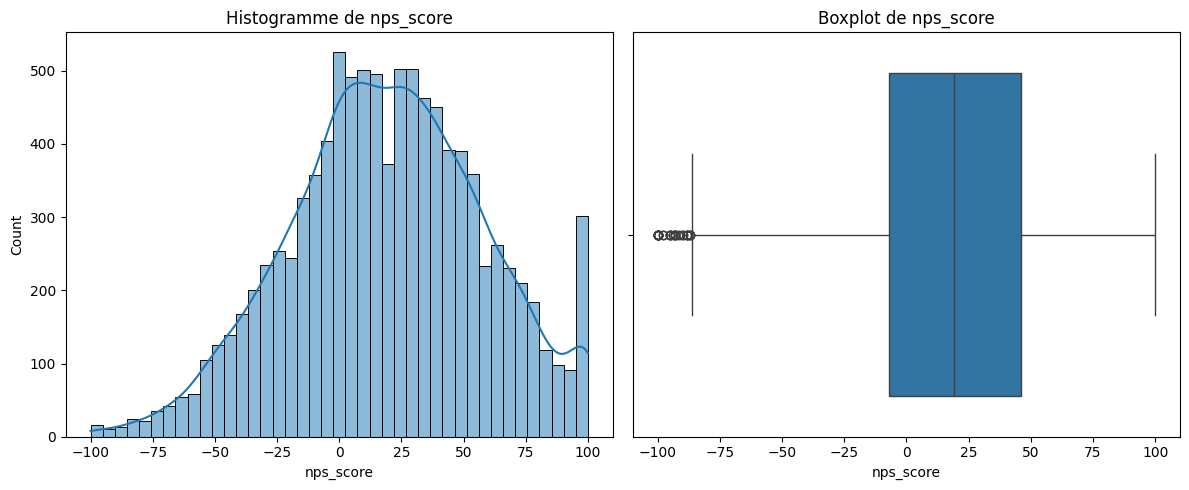

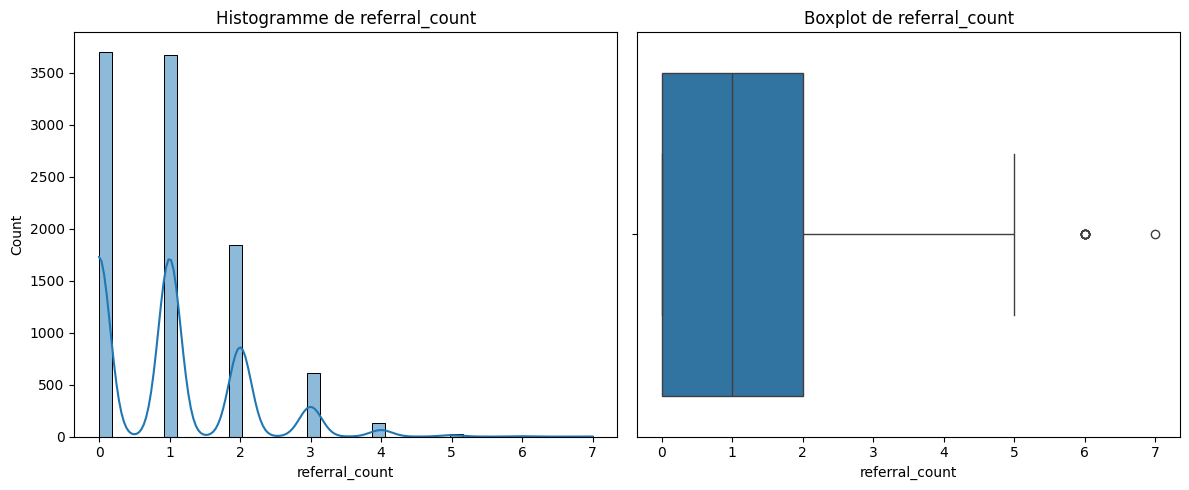

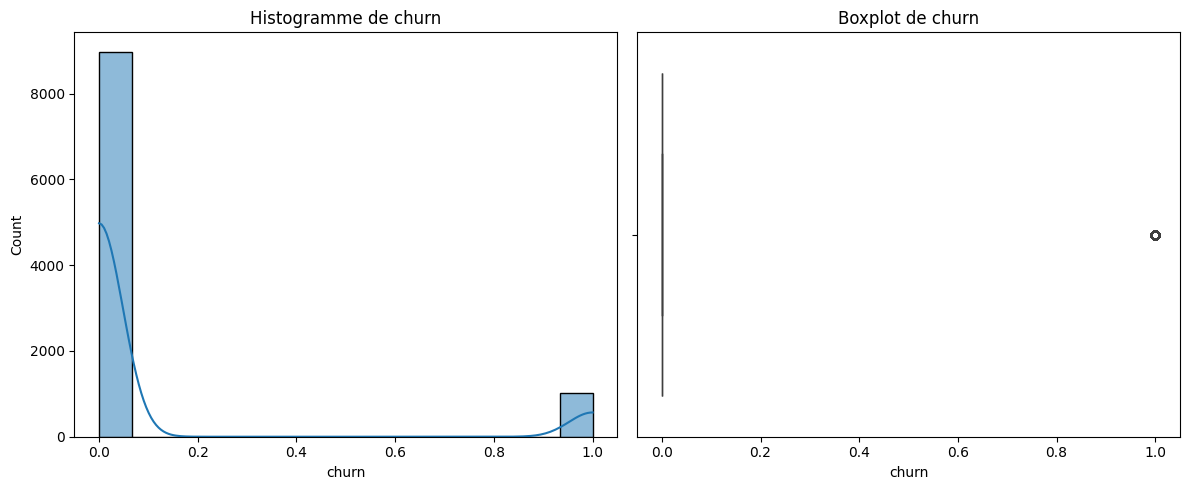

In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogramme de {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()


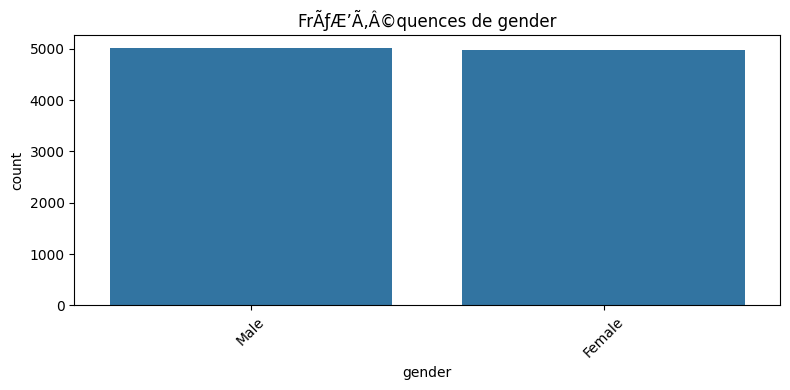

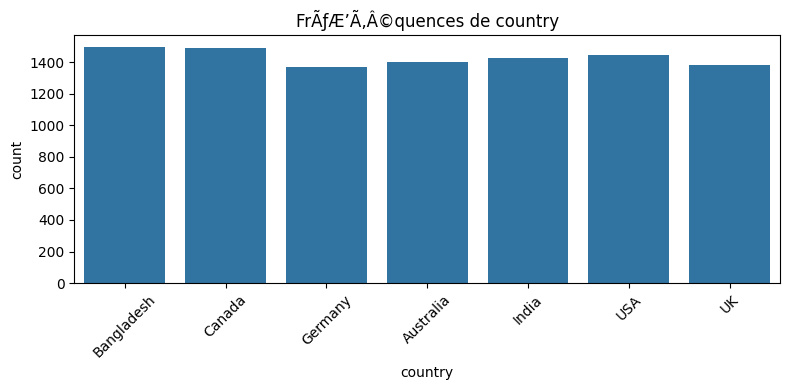

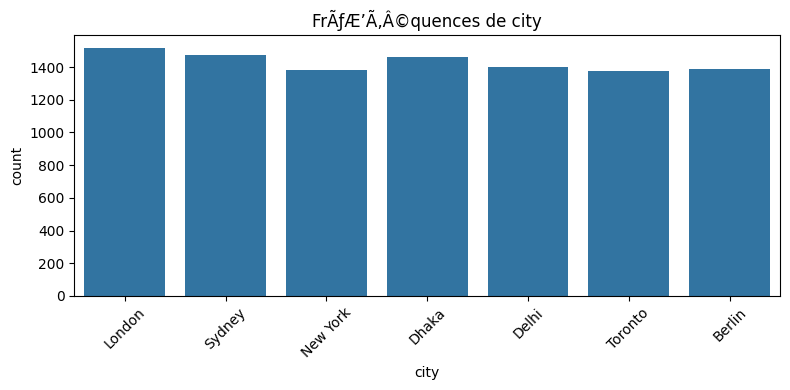

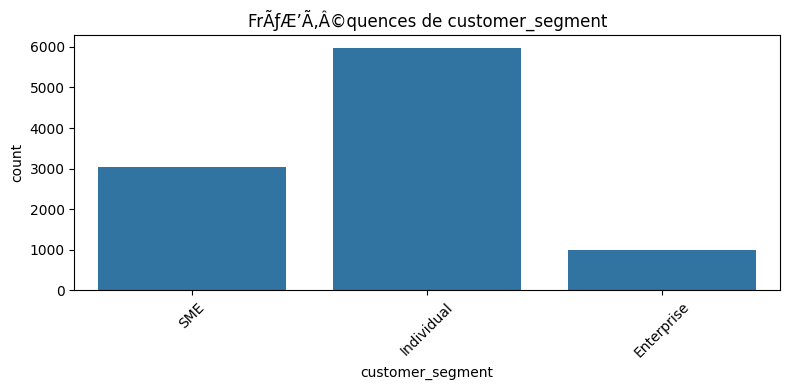

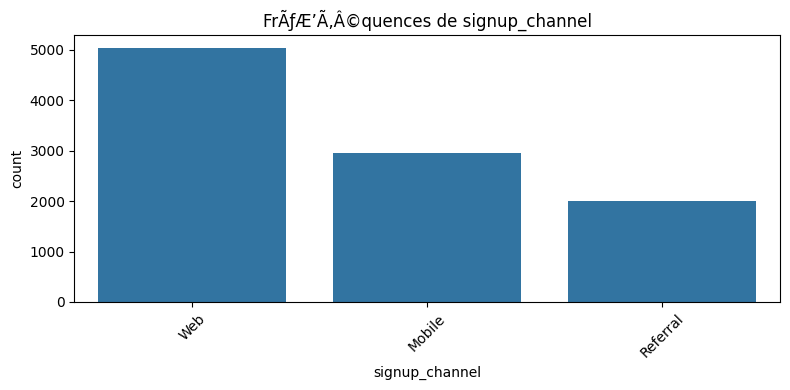

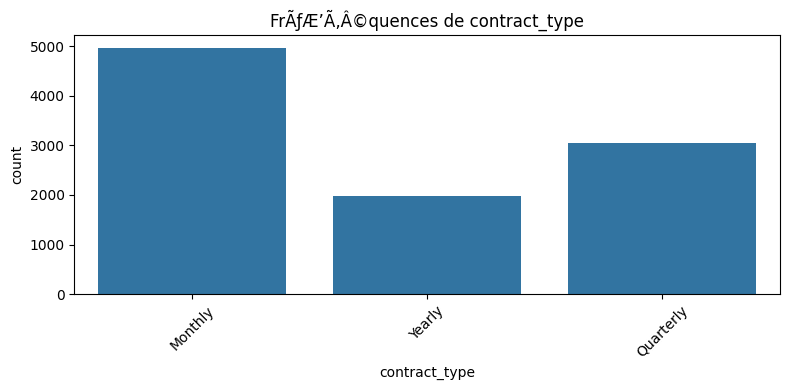

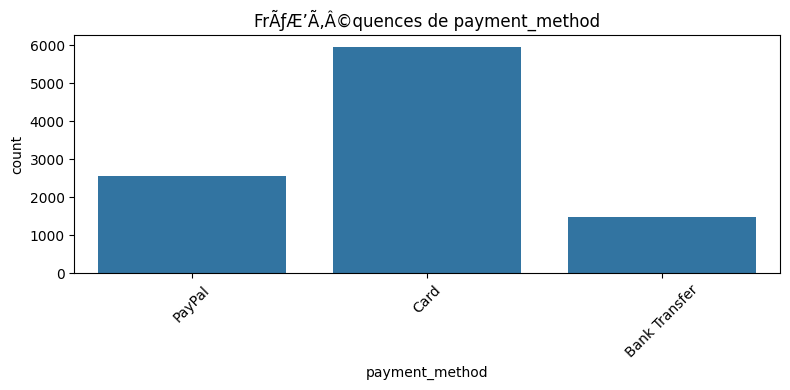

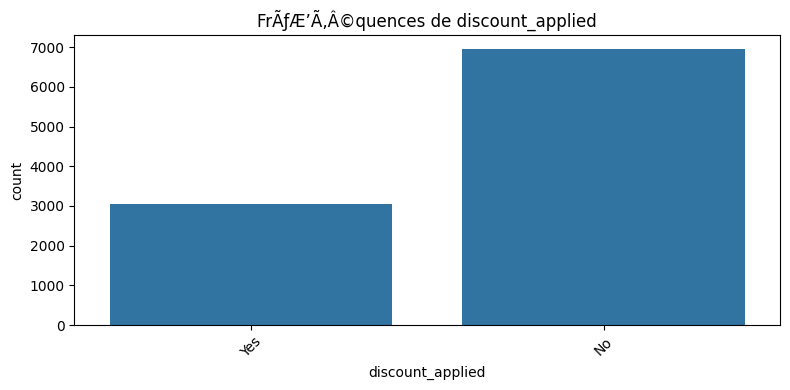

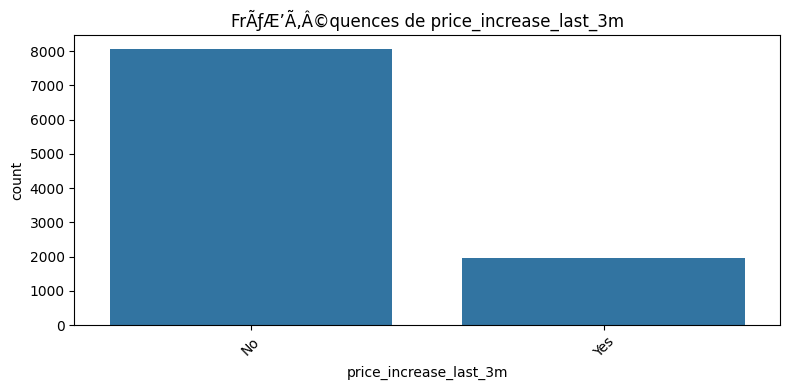

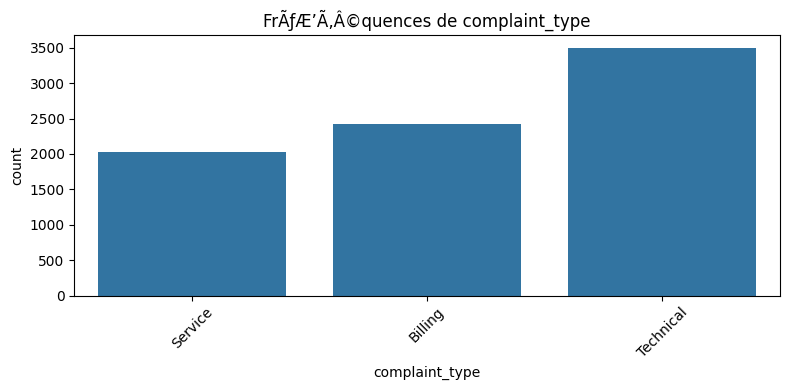

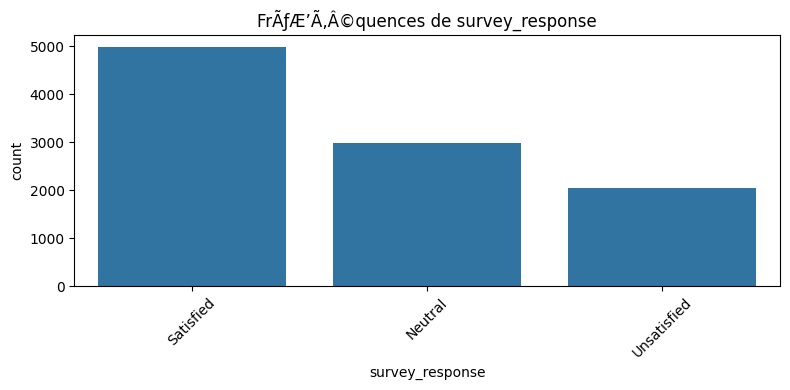

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col])
    plt.title(f'Fréquences de {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


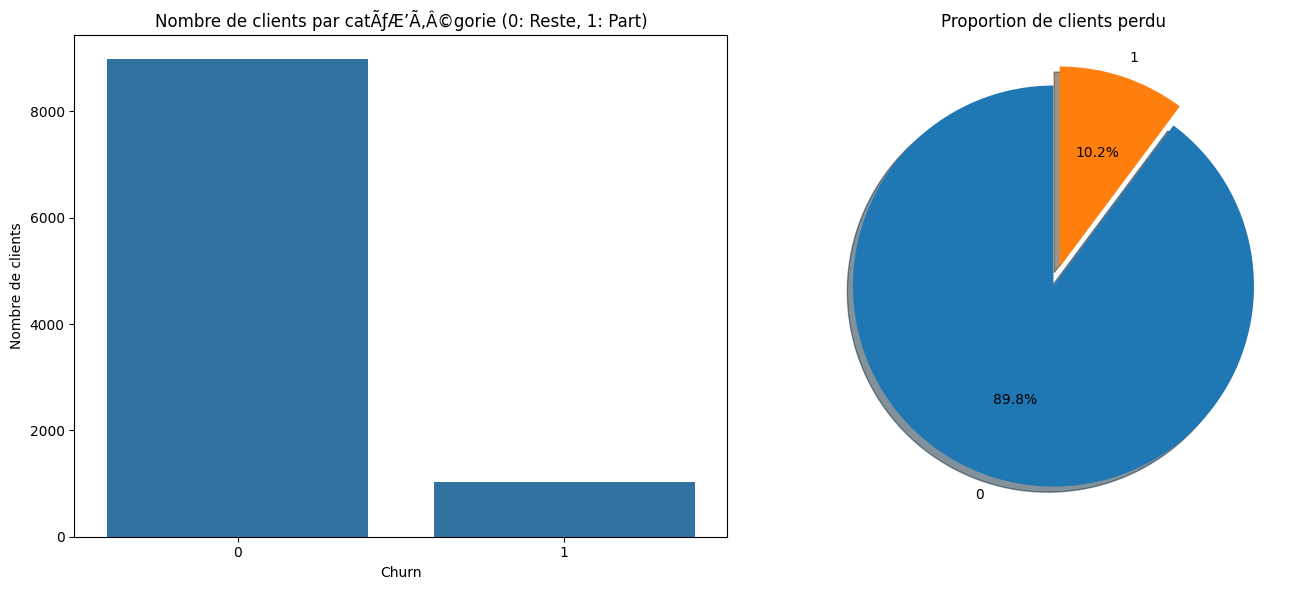

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='churn', data=df, ax=ax[0]) # graphique en barres (Countplot)
ax[0].set_title('Nombre de clients par catÃƒÆ’Ã‚Â©gorie (0: Reste, 1: Part)')
ax[0].set_xlabel('Churn')
ax[0].set_ylabel('Nombre de clients')

df['churn'].value_counts().plot.pie( #camembert (Pie chart) pour les proportions
    autopct='%1.1f%%', 
    ax=ax[1], 
    startangle=90, 
    explode=[0, 0.1], 
    shadow=True
)
ax[1].set_title('Proportion de clients perdu')
ax[1].set_ylabel('') #retire le label

plt.tight_layout()
plt.show()


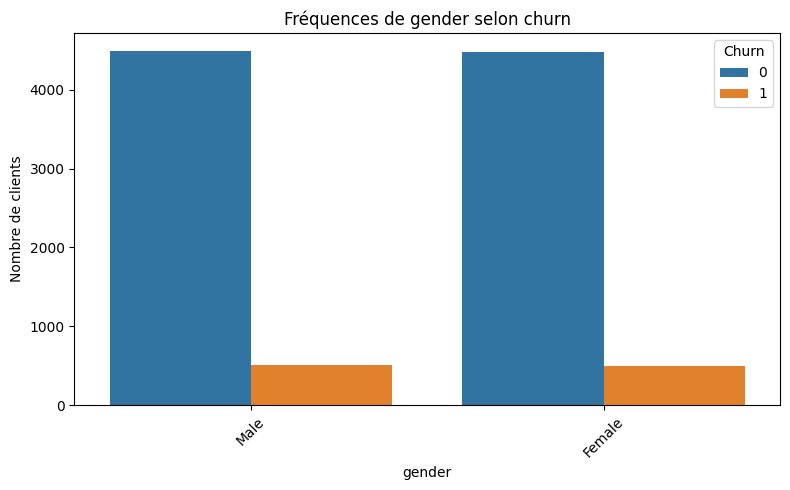

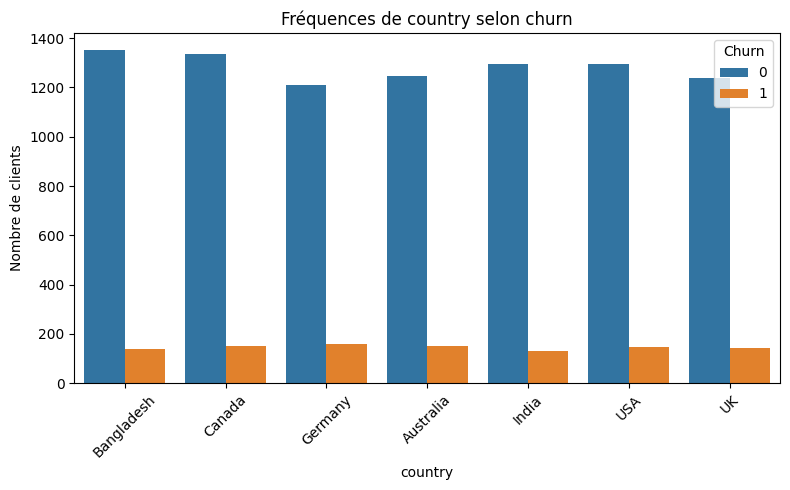

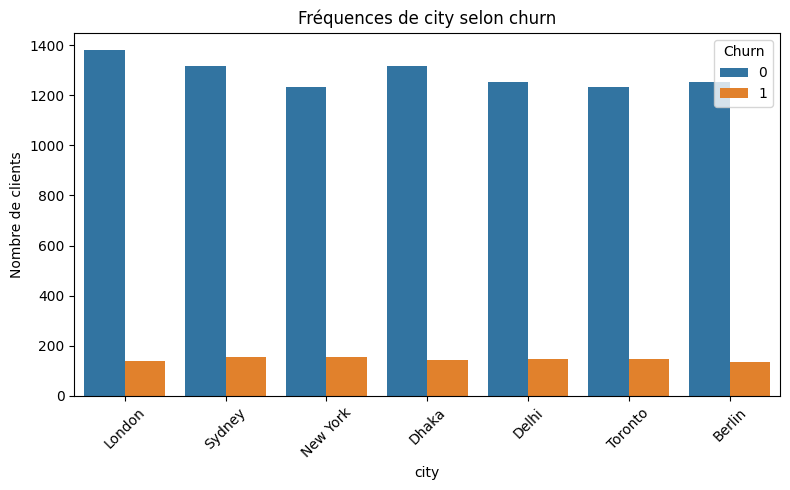

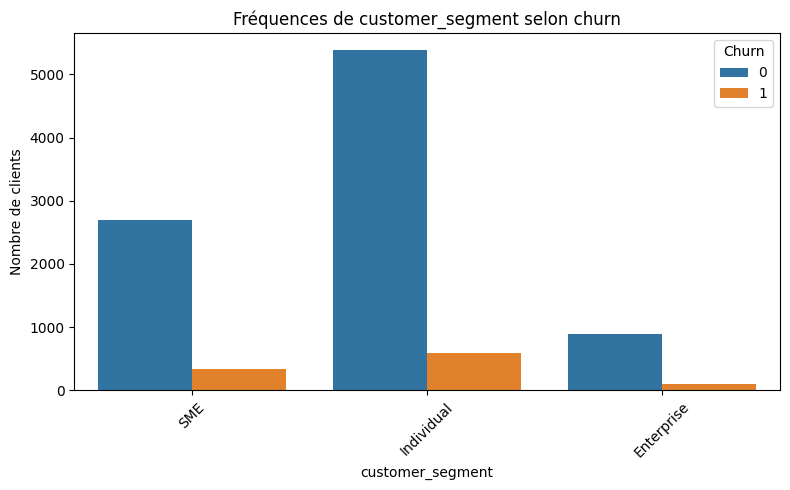

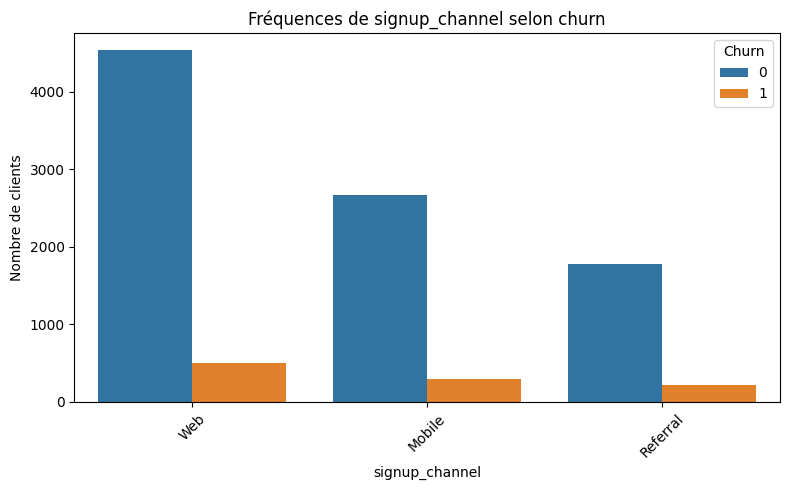

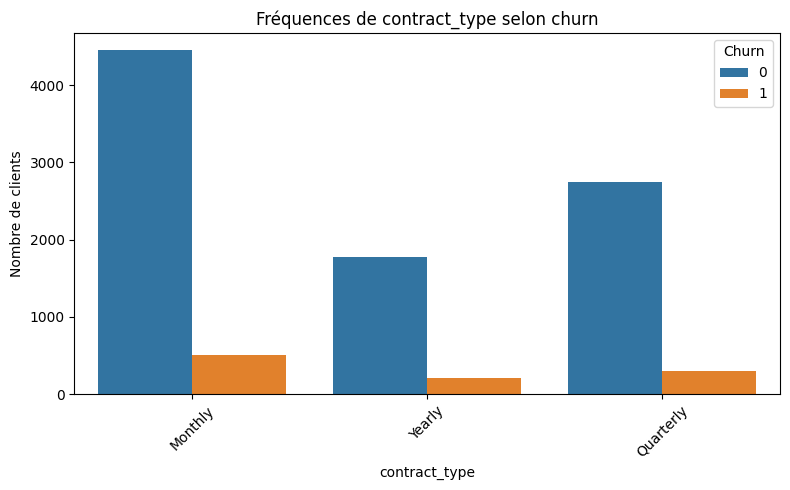

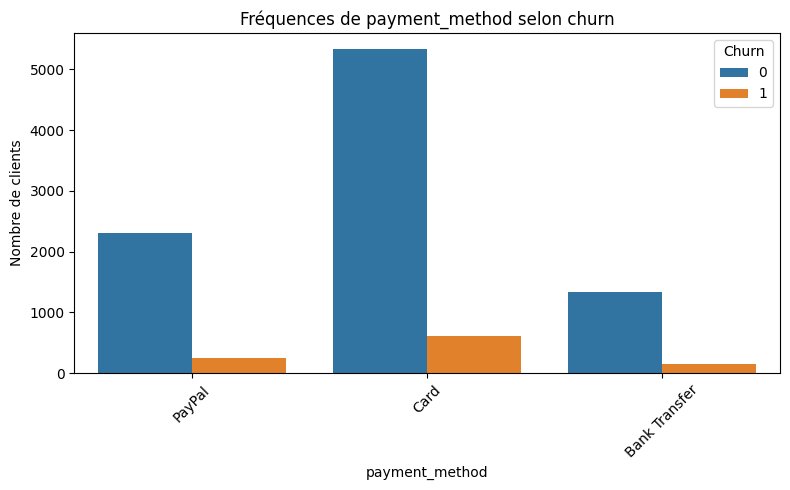

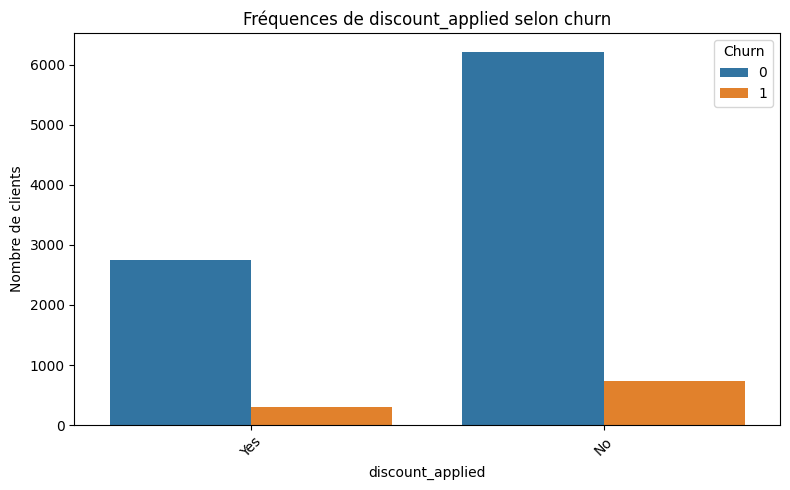

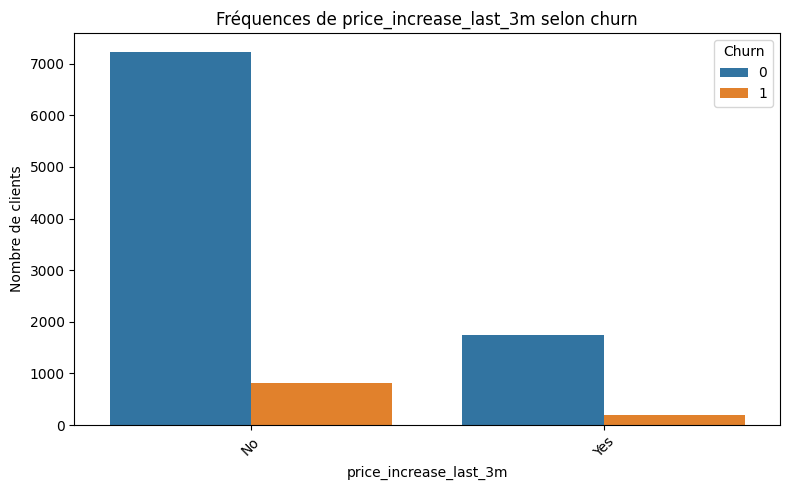

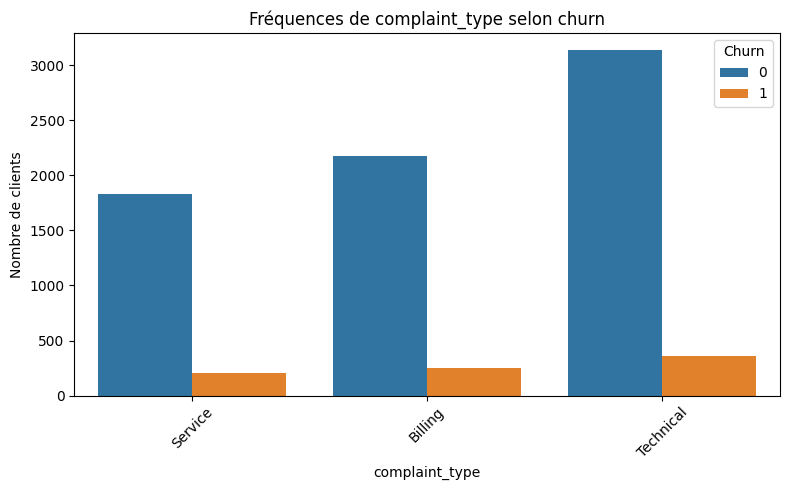

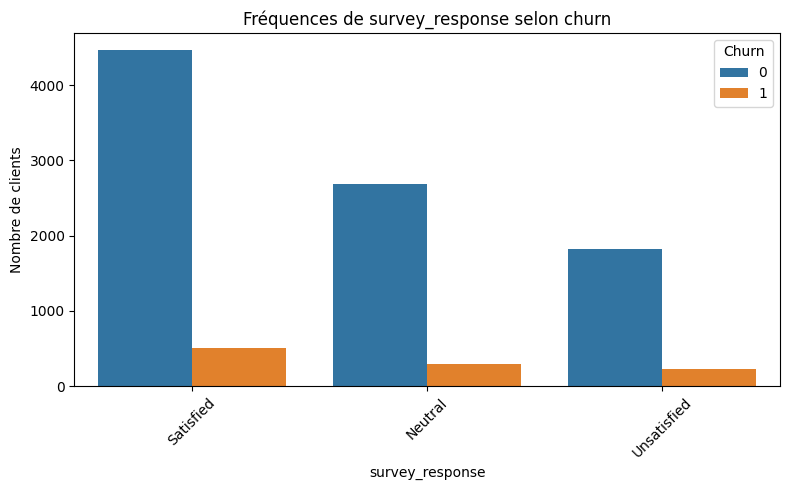

In [11]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue='churn', data=df)
    plt.title(f'Fréquences de {col} selon churn')
    plt.xlabel(col)
    plt.ylabel('Nombre de clients')
    plt.legend(title='Churn', loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


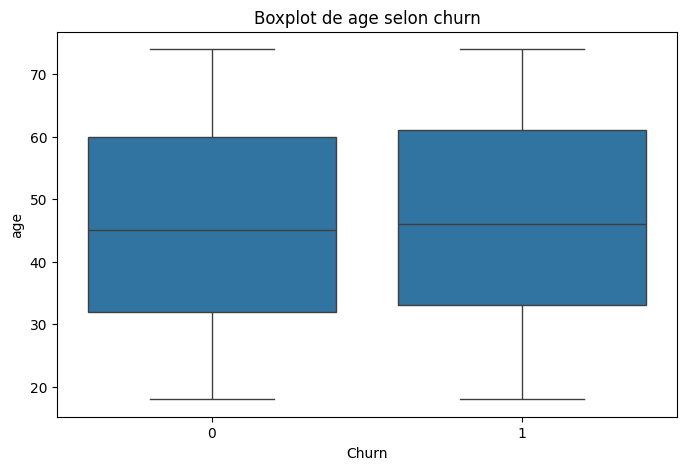

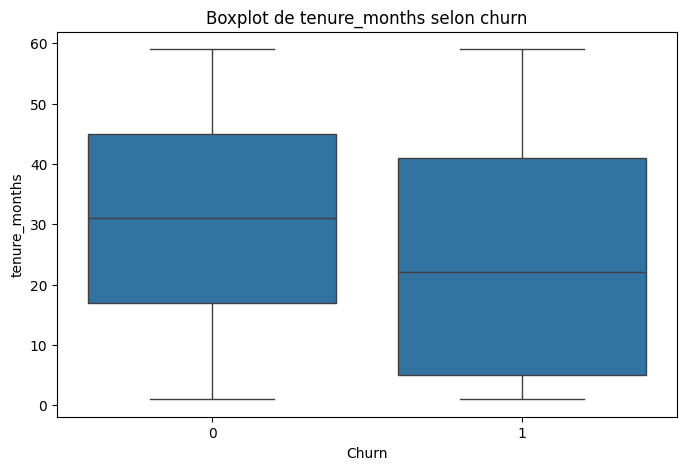

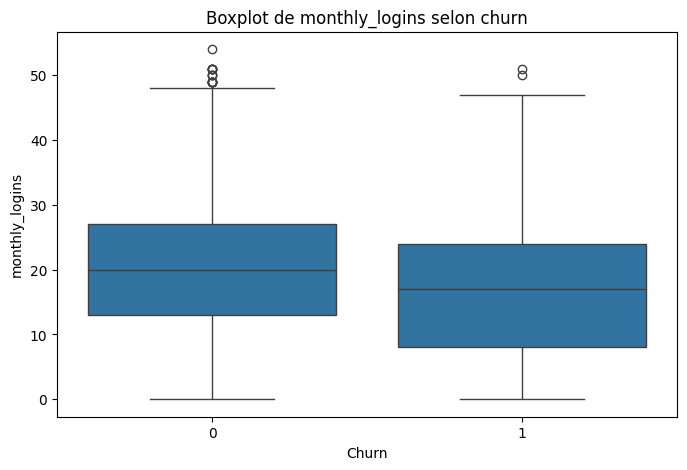

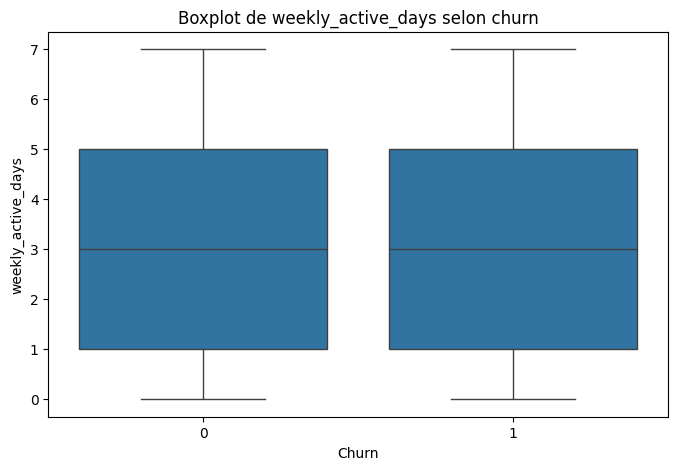

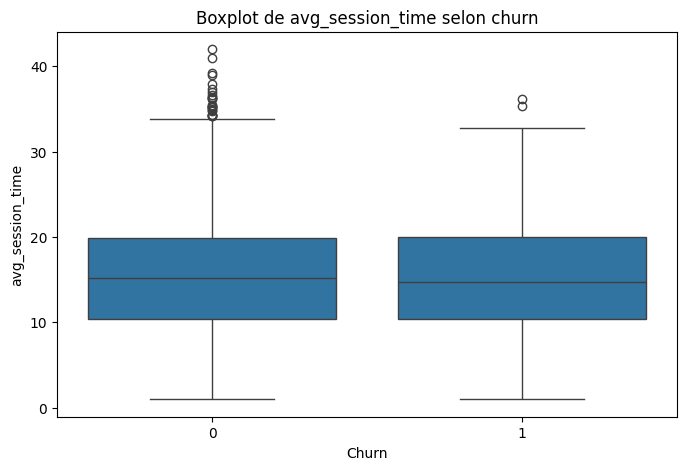

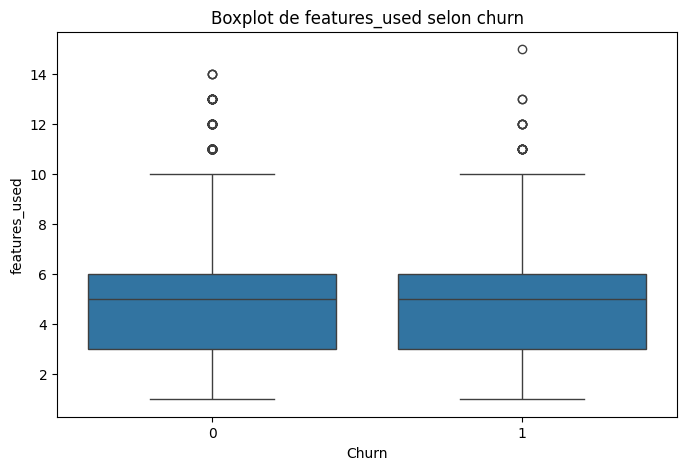

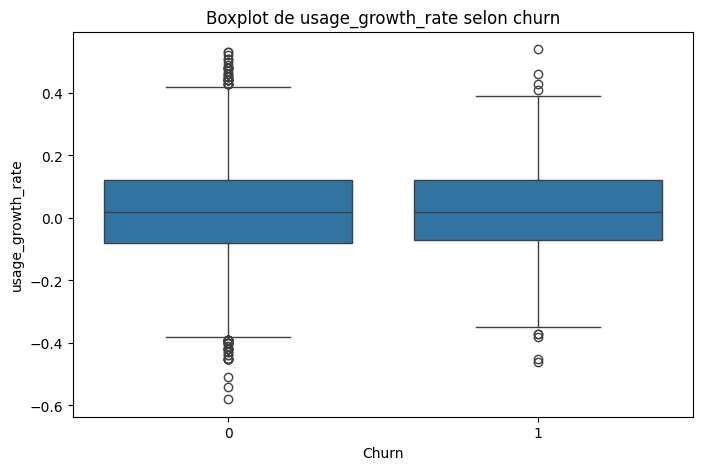

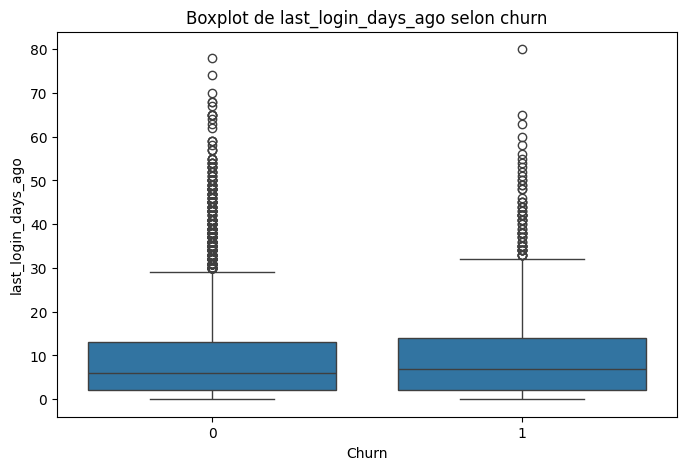

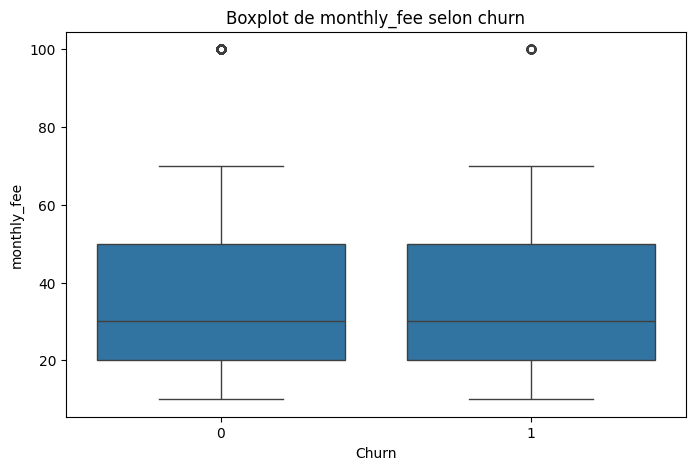

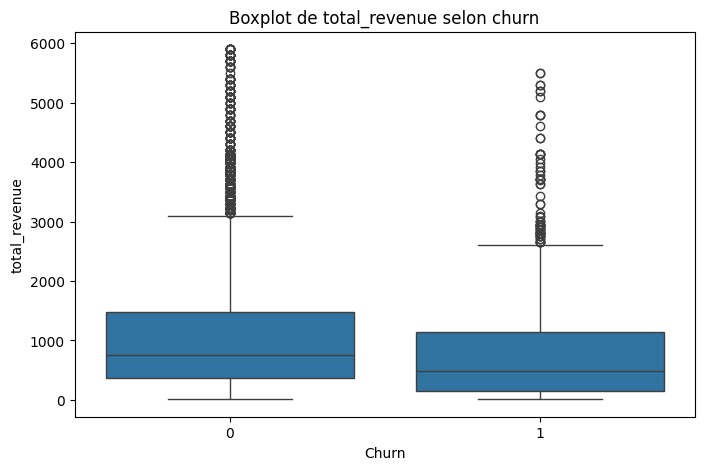

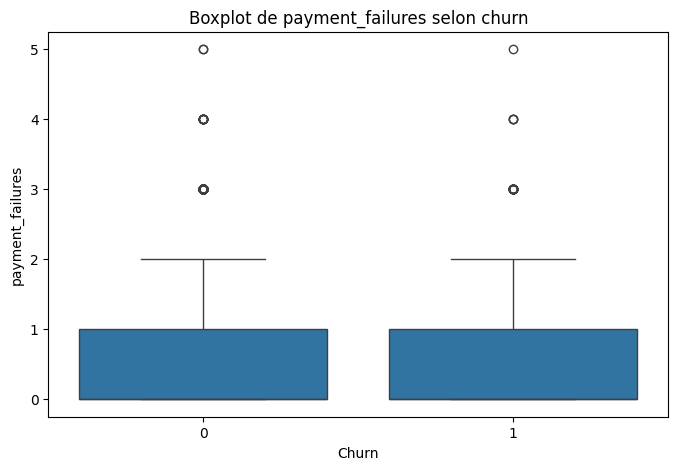

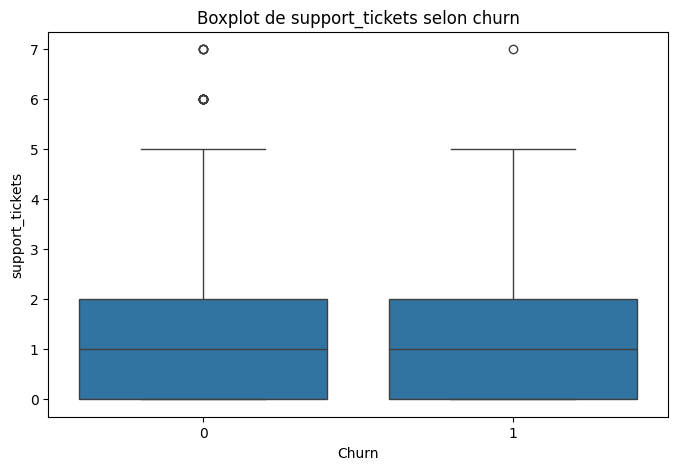

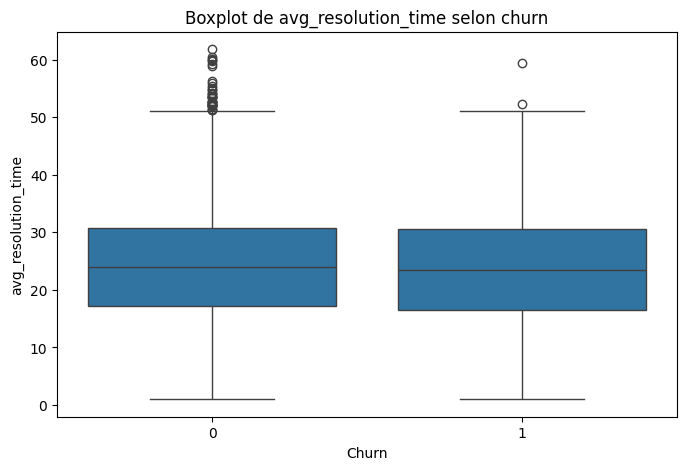

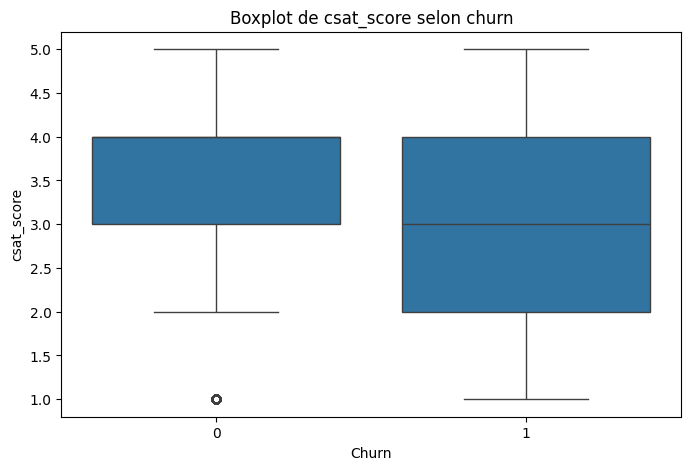

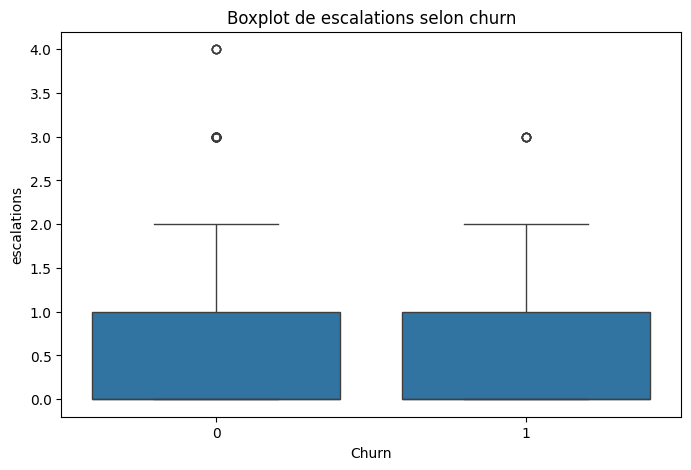

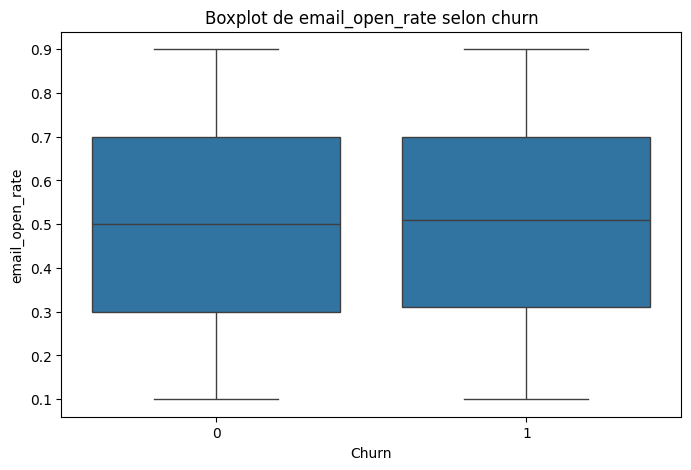

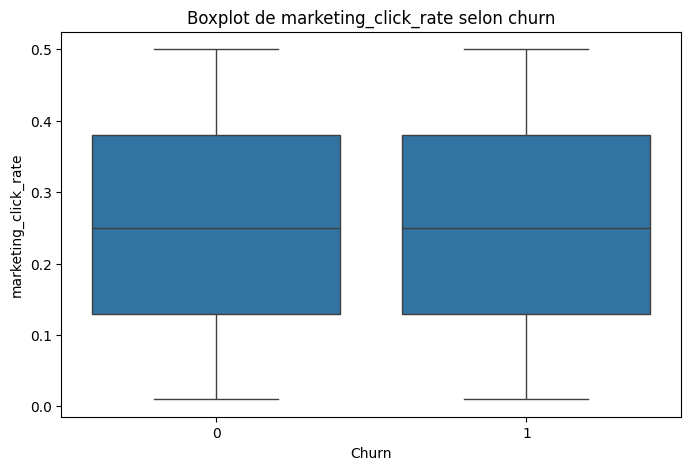

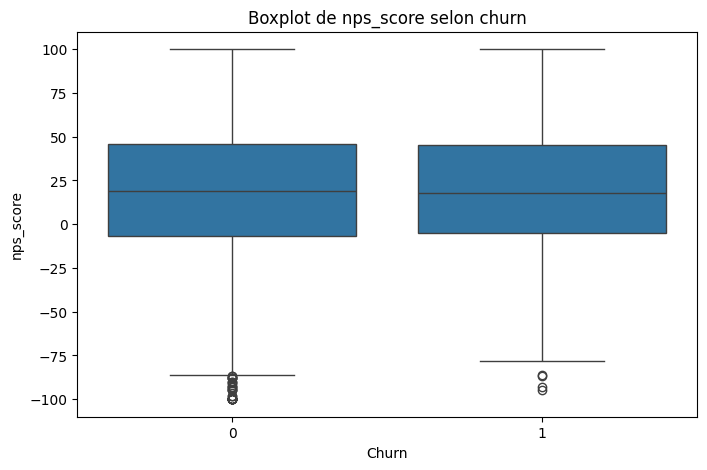

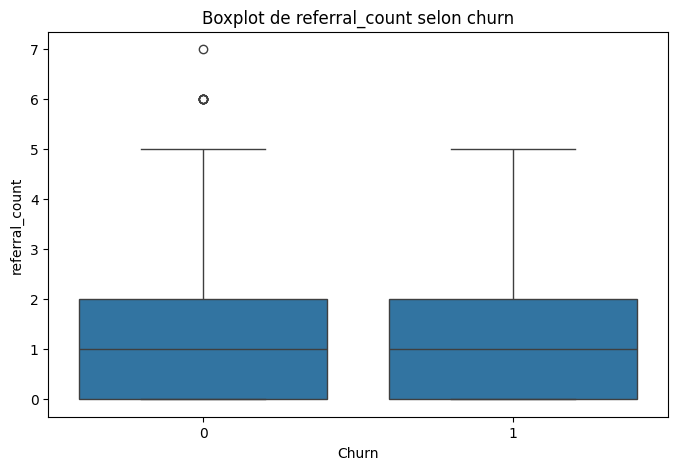

In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.drop('churn')
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='churn', y=col, data=df)
    plt.title(f'Boxplot de {col} selon churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.show()


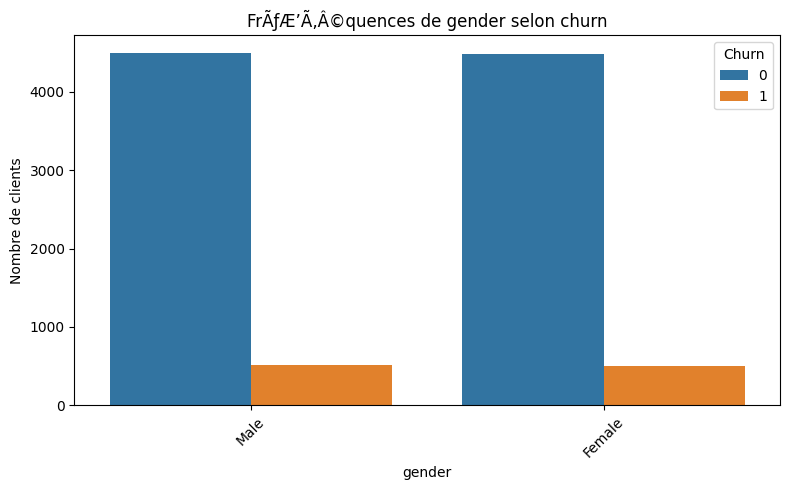

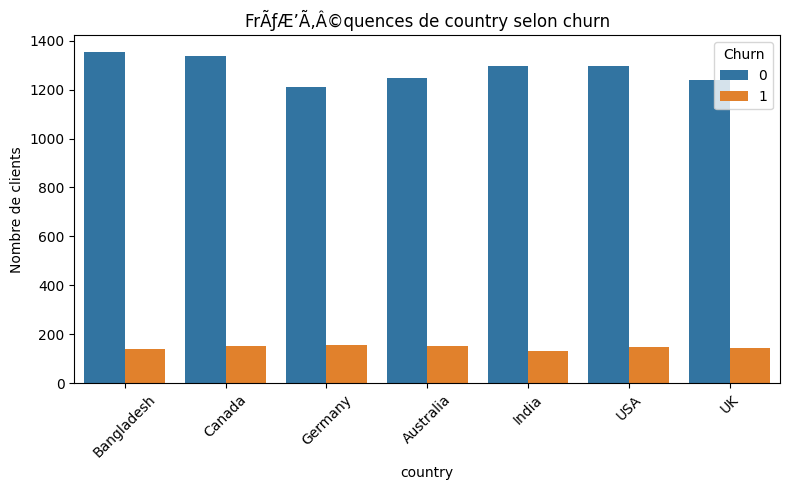

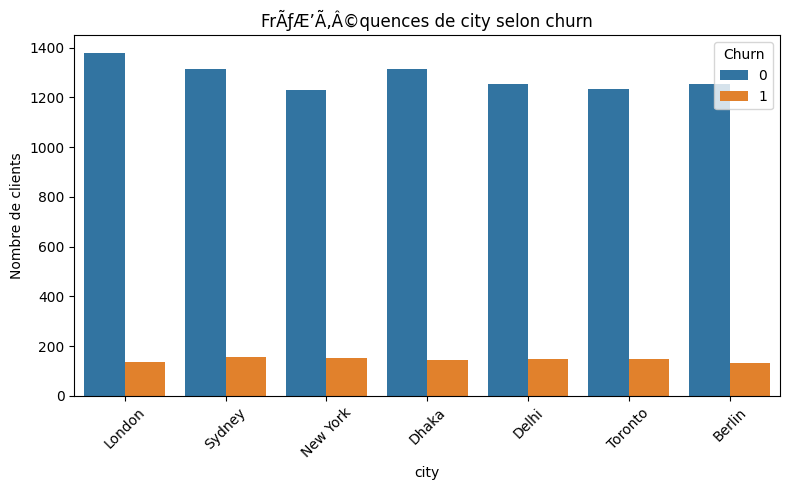

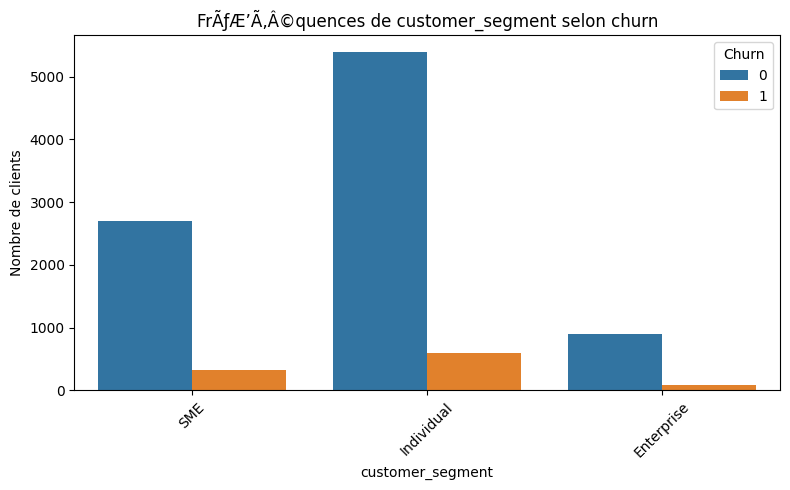

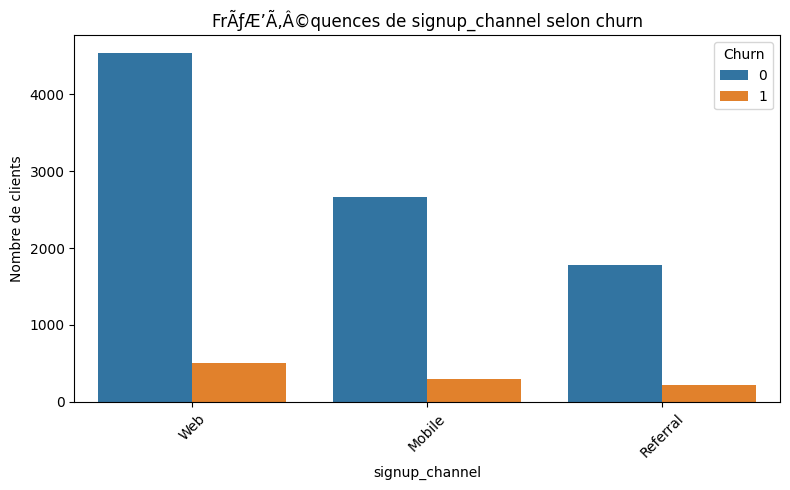

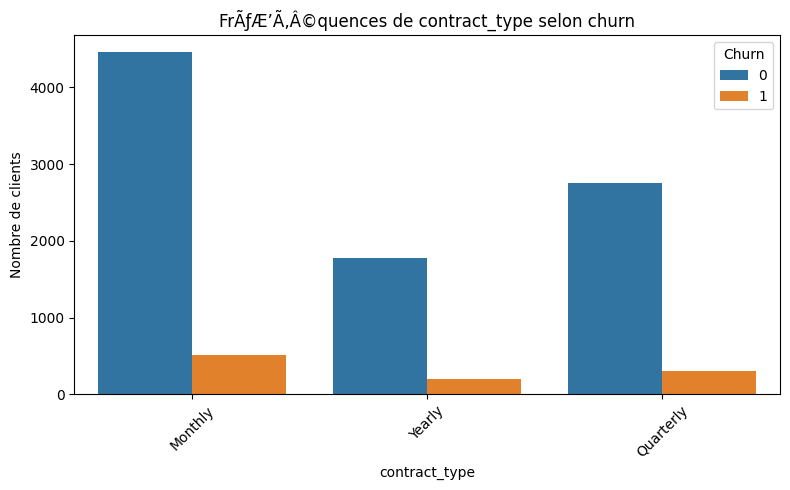

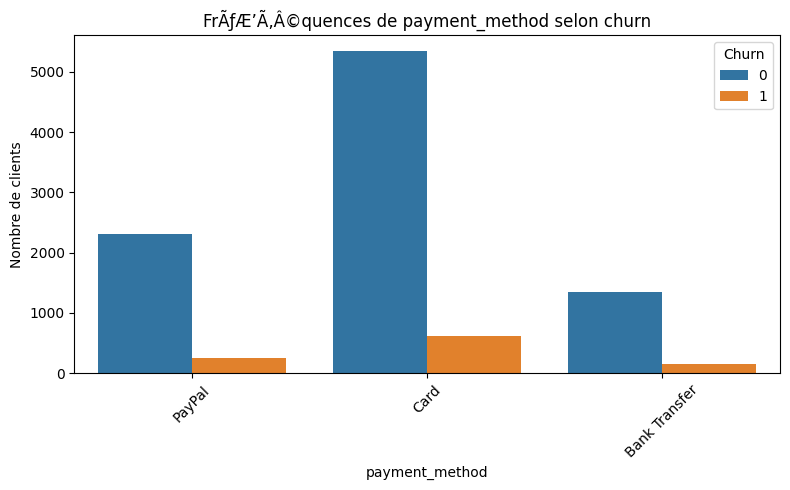

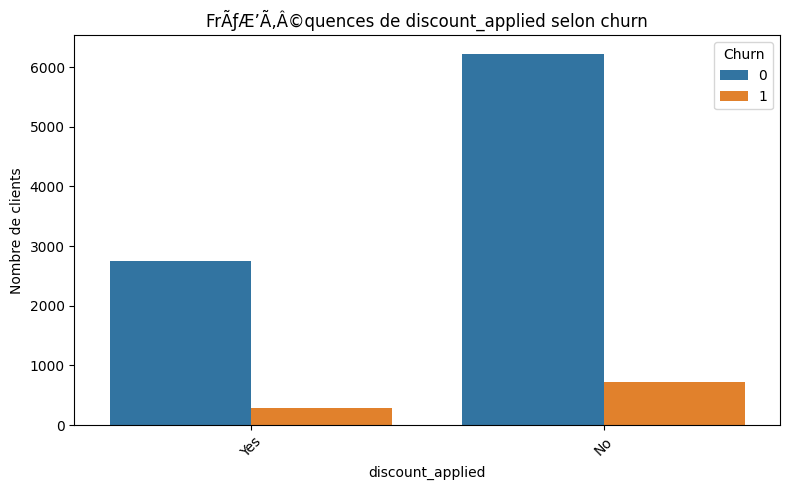

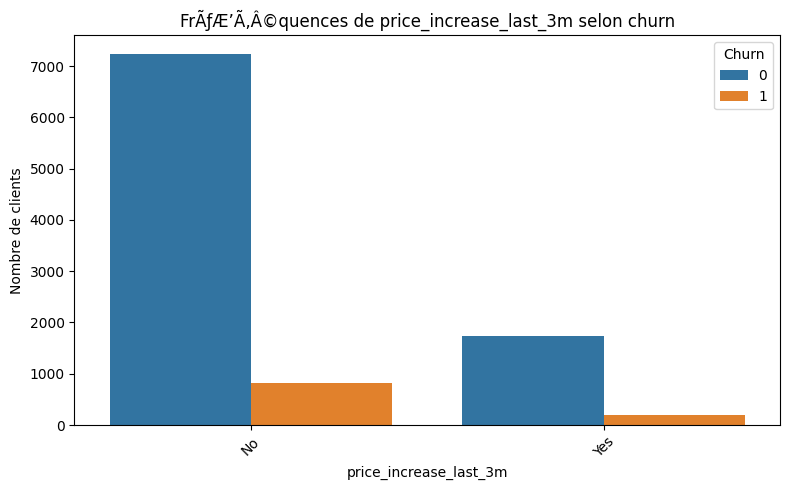

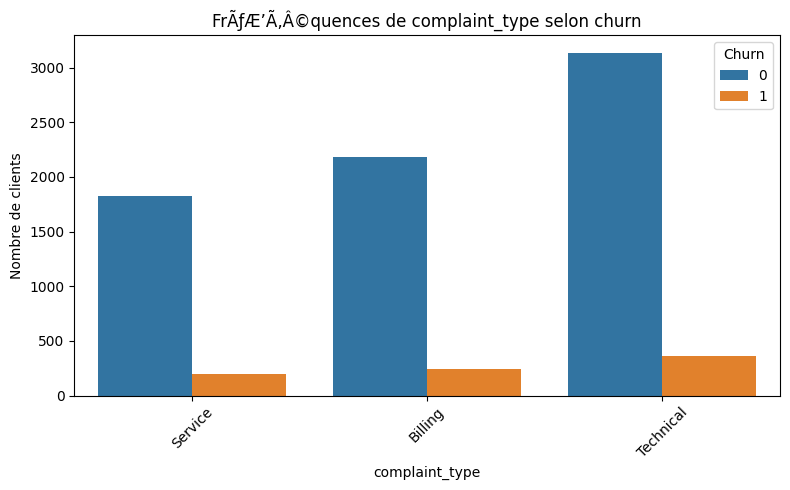

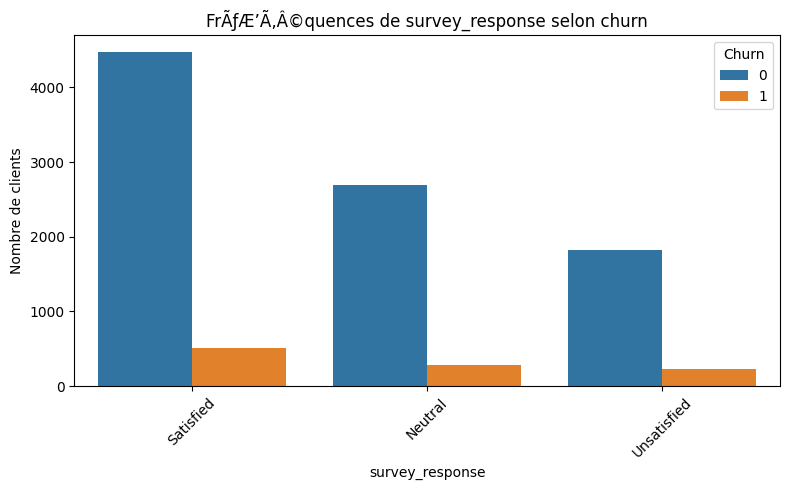

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue='churn', data=df)
    plt.title(f'Fréquences de {col} selon churn')
    plt.xlabel(col)
    plt.ylabel('Nombre de clients')
    plt.legend(title='Churn', loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

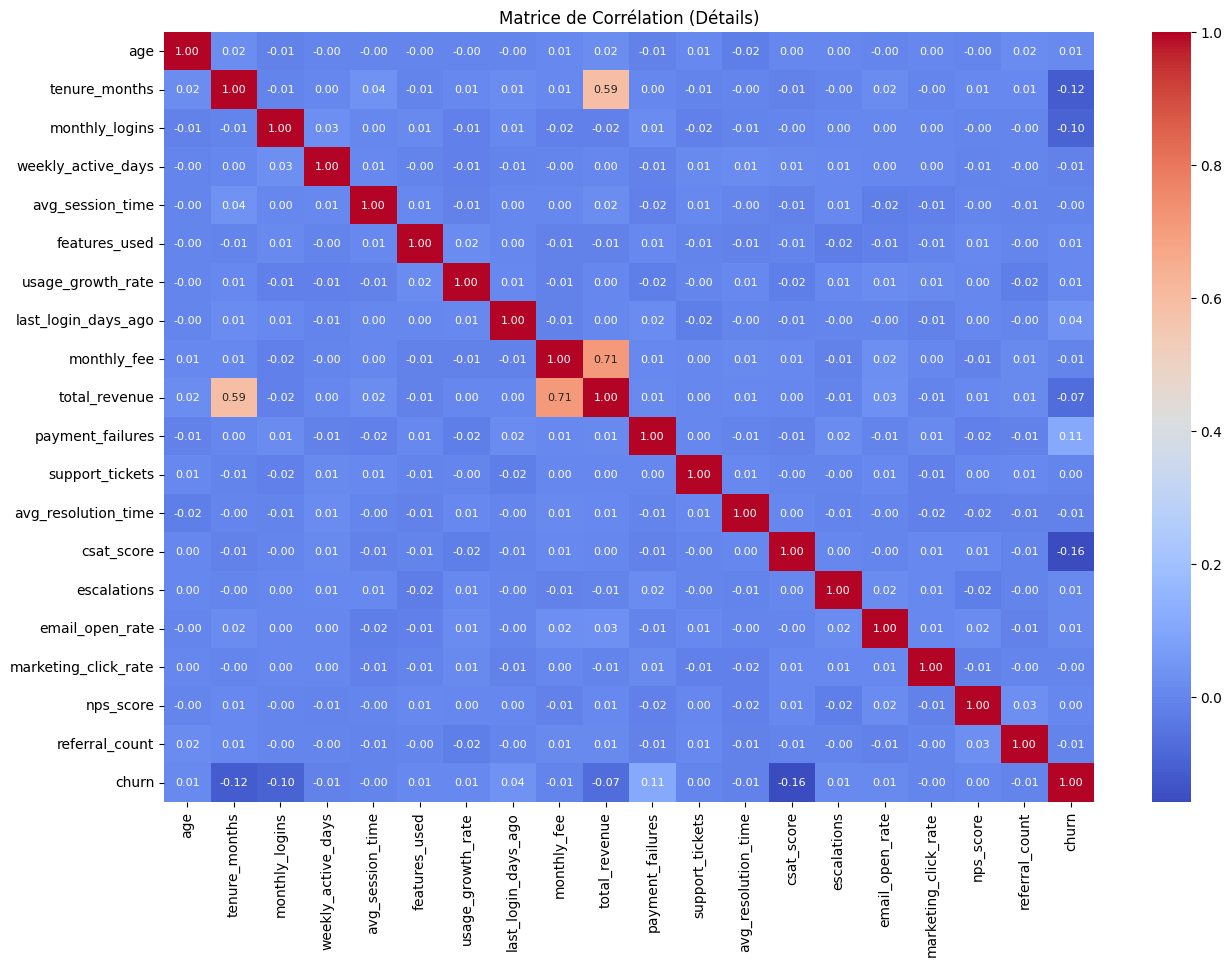

In [12]:
df_corr = df.copy()
label_encoder = LabelEncoder()
for col in df_corr.select_dtypes(include=["object"]).columns:
    df_corr[col] = label_encoder.fit_transform(df_corr[col].astype(str))

plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', annot_kws={'size': 8})
plt.title('Matrice de Corrélation (Détails)')
plt.show()

## Conclusion de l'EDA
L'analyse exploratoire a permis de mettre en évidence :
- Les variables corrélées au churn (tenure, support tickets, etc.).
- La distribution des classes (déséquilibre à prendre en compte).
- Les types de données et les besoins en prétraitement.

**Étape suivante :** Préparation des données et Feature Engineering dans le notebook `02_preprocessing.ipynb`.